# [RSNA 2023 Abdominal Trauma Detection](https://www.kaggle.com/competitions/rsna-2023-abdominal-trauma-detection)

> Detect and classify traumatic abdominal injuries

![](https://www.kaggle.com/competitions/52254/images/header)

# 🧪 Experiment 1: `(ATD_Simple)`

* **ATD**= `Abdominal Trauma Detection`.
* **Simple** = Here it refer to experiment we will be conducting **without using any kind of data augmentation**.

## Step 1: Downloading And Extracting Data From Kaggle
🔑 **Note**: You will need your personal kaggle api key as kaggle.json that you can get on kaggle.

In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d jayantarsode/rsna-abdominal-trauma-subset

100% 6.52G/6.54G [01:00<00:00, 152MB/s]
100% 6.54G/6.54G [01:00<00:00, 117MB/s]


In [ ]:
!unzip /content/rsna-abdominal-trauma-subset.zip

## Step 2: Installing Important Libraries

In [ ]:
!pip install torchmetrics
!pip install wandb onnx -Uq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 841.5/841.5 kB 11.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 59.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 61.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 88.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 14.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 30.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 8.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 MB 10.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 14.4 MB/s eta 0:00:00
     ━━━━━━━━━━━

## Step 3: Setting Up Device We Will Work In.

In [ ]:
import torch
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
# Device configuration
if device=="cuda":
  !nvidia-smi
else:
  !cat /proc/cpuinfo

Mon Mar 25 10:06:40 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla V100-SXM2-16GB           Off | 00000000:00:04.0 Off |                    0 |
| N/A   35C    P0              24W / 300W |      2MiB / 16384MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

## Step 4: Importing and Using Our Custom Module [torch_helper_functions](https://drive.google.com/drive/folders/11e2iSHGQ9d-DeONfYe7nyY1v09IC1lFh?usp=sharing)

In [ ]:
# Importing custom module
!unzip /content/torch_helper_functions-20240303T140413Z-001.zip

Archive:  /content/torch_helper_functions-20240303T140413Z-001.zip
  inflating: torch_helper_functions/multilabel/train_engine.py  
  inflating: torch_helper_functions/multilabel/data_cleaner.py  
  inflating: torch_helper_functions/plotting_utils.py  
  inflating: torch_helper_functions/utils.py  
  inflating: torch_helper_functions/multilabel/data_setup.py  


## Step 5: Importing the patients_with_abnormalities.csv that we got During [data cleaning and analysis](https://colab.research.google.com/drive/1RZLF4R20jLazr9NH_R4Yv6RIw7gZiB4e?usp=sharing).

In [ ]:
# Importing train_valid_images.csv
import pandas as pd
patients_with_abnormalities=pd.read_csv('/content/patients_with_abnormalities.csv').drop(columns=['Unnamed: 0'])
patients_with_abnormalities.head()

,image_path,bowel_healthy,bowel_injury,extravasation_healthy,extravasation_injury,kidney_healthy,kidney_low,kidney_high,liver_healthy,liver_low,liver_high,spleen_healthy,spleen_low,spleen_high
0,/content/train_images/32982/5503/1000.png,1,0,1,0,1,0,0,1,0,0,0,1,0
1,/content/train_images/32982/5503/1001.png,1,0,1,0,1,0,0,1,0,0,0,1,0
2,/content/train_images/32982/5503/1002.png,1,0,1,0,1,0,0,1,0,0,0,1,0
3,/content/train_images/32982/5503/1003.png,1,0,1,0,1,0,0,1,0,0,0,1,0
4,/content/train_images/32982/5503/1004.png,1,0,1,0,1,0,0,1,0,0,0,1,0


## Step 6: Setting Up Dataloaders for Training,Validation and Testing

In [ ]:
# Importing important libraries
from torch_helper_functions.multilabel import data_setup
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Label Columns to Select
label_columns = [ 'bowel_injury',
                  'extravasation_injury',
                  'kidney_healthy', 'kidney_low','kidney_high',
                  'liver_healthy', 'liver_low', 'liver_high',
                  'spleen_healthy', 'spleen_low', 'spleen_high']

In [ ]:
from torchvision import transforms
from torch_helper_functions.multilabel import data_setup
IMAGE_SIZE= 256
BATCH_SIZE = 32

# Creating a simple transform which resize image and convert it into tensor
simple_transform = transforms.Compose([
    transforms.Resize(size=(IMAGE_SIZE,IMAGE_SIZE)),
    transforms.ToTensor()
]
)

# Loading the dataloader train,validation and test
train_dataloader, val_dataloader, test_dataloader, classes = data_setup.create_dataloaders_from_dataframe(patients_with_abnormalities,
                                                                                                         'image_path',
                                                                                                         label_columns,
                                                                                                         transform=simple_transform,
                                                                                                         batch_size=BATCH_SIZE,
                                                                                                         validation_split=0.15,
                                                                                                         test_split=0.15)

Each 1 instance in dataloader=32 data points.
Train DataLoader contains: 1918 instance = 61353 data points.
Validation DataLoader contains: 339 instance = 10827 data points.
Test DataLoader contains: 399 instance = 12738 data points.


In [ ]:
print(f"The labels in dataset are: \n{','.join(classes)}")

The labels in dataset are: 
bowel_injury,extravasation_injury,kidney_healthy,kidney_low,kidney_high,liver_healthy,liver_low,liver_high,spleen_healthy,spleen_low,spleen_high


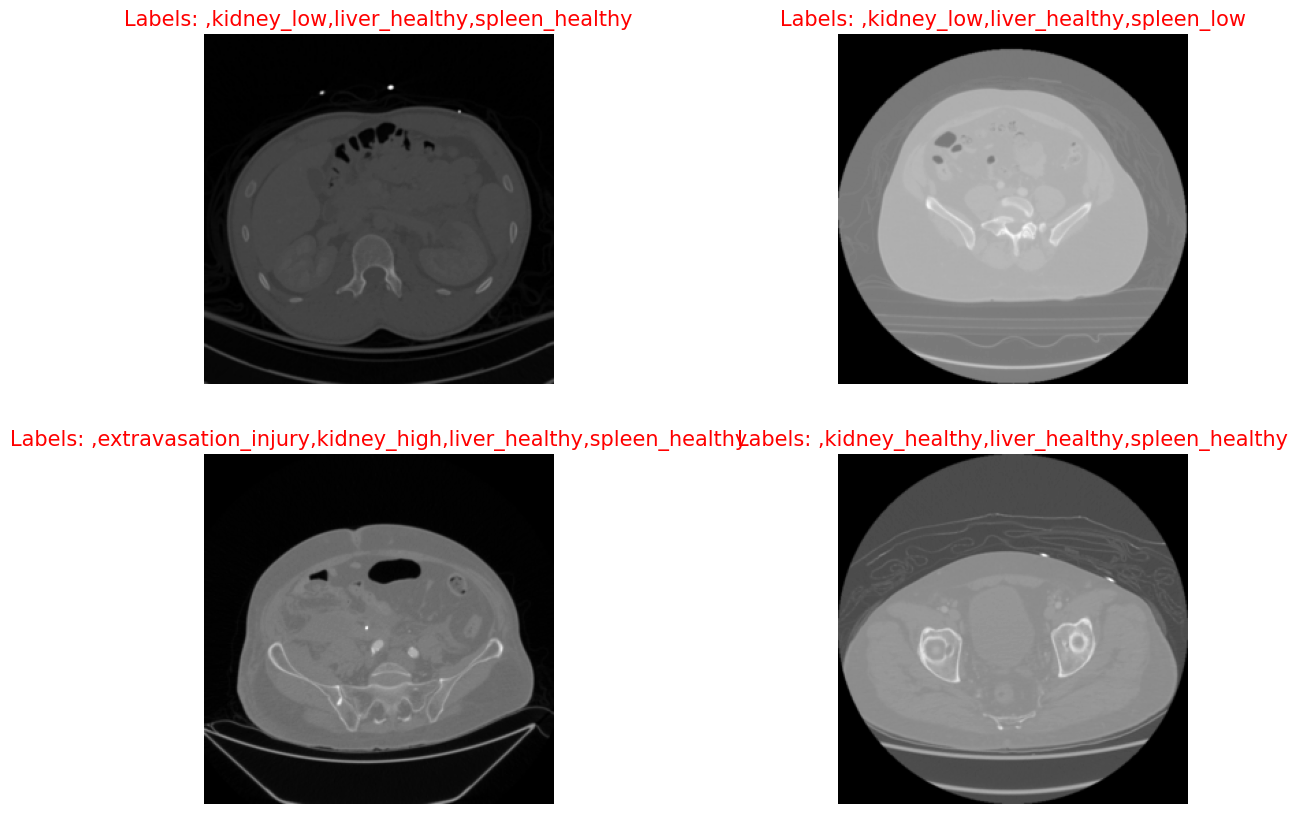

In [ ]:
import random
import matplotlib.pyplot as plt
# Visualizing labels and images
images,y_bowel, y_extra, y_kidney, y_liver, y_spleen = next(iter(train_dataloader))
# Display sample data and labels
fig,ax = plt.subplots(2,2,figsize=(15,10))
ax = ax.ravel()
for k in range(4):
  label=''
  i = random.choice(range(0,31))
  ax[k].imshow(images[i].permute(1,2,0),cmap="gray")
  if y_bowel[i].item()==1:
    label+=","+label_columns[0]
  if y_extra[i].item()==1:
    label+=","+label_columns[1]
  label+=","+label_columns[2+y_kidney[i].argmax()]
  label+=","+label_columns[5+y_liver[i].argmax()]
  label+=","+label_columns[8+y_spleen[i].argmax()]
  ax[k].set_title(f"Labels: {label}",c="r",fontsize=15)
  ax[k].axis("off")

## Step 7: Creating Our Model Architecture


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ATD_Base_Model(nn.Module):
    def __init__(self, input_shape=1):
        super().__init__()
        # Define your custom convolutional block
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=32,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32,
                      out_channels=64,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=64,
                      out_channels=32,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32,
                      out_channels=64,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        num_features = 64*64*64
        self.flatten=nn.Flatten()
        self.dropout = nn.Dropout(p=0.5)
        self.bowel_head = nn.Sequential(
            nn.Linear(num_features, 100),
            nn.SiLU(),
            nn.Linear(100, 1)
        )
        self.extra_head = nn.Sequential(
            nn.Linear(num_features, 100),
            nn.SiLU(),
            nn.Linear(100, 1)
        )
        self.kidney_head = nn.Sequential(
            nn.Linear(num_features, 100),
            nn.SiLU(),
            nn.Linear(100, 3)
        )
        self.liver_head = nn.Sequential(
            nn.Linear(num_features, 100),
            nn.SiLU(),
            nn.Linear(100, 3)
        )
        self.spleen_head = nn.Sequential(
            nn.Linear(num_features, 100),
            nn.SiLU(),
            nn.Linear(100, 3)
        )

    def forward(self, x):
        x =  self.dropout(self.flatten(self.conv_block_2(self.conv_block_1(x))))
        bowel_out = self.bowel_head(x)
        extra_out = self.extra_head(x)
        kidney_out = self.kidney_head(x)
        liver_out = self.liver_head(x)
        spleen_out = self.spleen_head(x)
        return bowel_out, extra_out,  kidney_out, liver_out, spleen_out

## Step 8: Instantiate Model And Getting Model Summary

In [ ]:
# Install torchinfo, import if it's availabel
try:
  import torchinfo
except:
  !pip install torchinfo
  import torchinfo

In [ ]:
torch.manual_seed(42)
INPUT_SHAPE=1
ATD_Simple_Model = ATD_Base_Model(input_shape=INPUT_SHAPE).to(device)

In [ ]:
# Getting model architecture
from torchinfo import summary
summary(ATD_Simple_Model,input_size=[BATCH_SIZE,INPUT_SHAPE,IMAGE_SIZE,IMAGE_SIZE])

Layer (type:depth-idx)                   Output Shape              Param #
ATD_Base_Model                           [32, 1]                   --
├─Sequential: 1-1                        [32, 64, 128, 128]        --
│    └─Conv2d: 2-1                       [32, 32, 256, 256]        320
│    └─ReLU: 2-2                         [32, 32, 256, 256]        --
│    └─Conv2d: 2-3                       [32, 64, 256, 256]        18,496
│    └─BatchNorm2d: 2-4                  [32, 64, 256, 256]        128
│    └─ReLU: 2-5                         [32, 64, 256, 256]        --
│    └─MaxPool2d: 2-6                    [32, 64, 128, 128]        --
├─Sequential: 1-2                        [32, 64, 64, 64]          --
│    └─Conv2d: 2-7                       [32, 32, 128, 128]        18,464
│    └─ReLU: 2-8                         [32, 32, 128, 128]        --
│    └─Conv2d: 2-9                       [32, 64, 128, 128]        18,496
│    └─BatchNorm2d: 2-10                 [32, 64, 128, 128]        128


### Step 8.1 Calculating class weights.
🔑 **Note**: We will be calculating class weigts due to more data imbalance as more patient are healthy and less have injuries.

In [ ]:
def binary_class_weights(df,label):
  class_counts = df[label].value_counts()
  total_samples = len(df[label])
  class_weights = torch.tensor([total_samples / (len(class_counts) * count) for count in class_counts]).float()
  return class_weights.to(device)
class_weights_bowel=binary_class_weights(patients_with_abnormalities,label_columns[0])
class_weights_extra=binary_class_weights(patients_with_abnormalities,label_columns[1])
print(f"Class weights bowel: {class_weights_bowel}")
print(f"Class weights extravasation: {class_weights_extra}")

Class weights bowel: tensor([ 0.5065, 39.0967], device='cuda:0')
Class weights extravasation: tensor([0.5753, 3.8217], device='cuda:0')


In [ ]:
def multiclass_class_weights(df,label):
    # Calculate class counts
    class_counts = df[label].sum(axis=0)

    # Calculate total samples
    total_samples = len(df[label])

    # Calculate class weights
    class_weights = torch.tensor([total_samples / count for count in class_counts]).float()

    return class_weights.to(device)
class_weights_kidney=multiclass_class_weights(patients_with_abnormalities,label_columns[2:5])
class_weights_liver=multiclass_class_weights(patients_with_abnormalities,label_columns[5:8])
class_weights_spleen=multiclass_class_weights(patients_with_abnormalities,label_columns[8:])
print(f"Class weights kidney: {class_weights_kidney}")
print(f"Class weights liver: {class_weights_liver}")
print(f"Class weights spleen: {class_weights_spleen}")

Class weights kidney: tensor([ 1.1534, 12.8352, 18.1604], device='cuda:0')
Class weights liver: tensor([ 1.2457,  6.4680, 23.4580], device='cuda:0')
Class weights spleen: tensor([ 1.2061,  9.0309, 16.6278], device='cuda:0')


## Step 9: Setting Up Hyperparameters And Loss,Metrics.

> **Loss Function** : [BCEWithLogitsLoss](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html),
[CROSSENTROPYLOSS](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)

🔑 **Note**: We have two diffrent loss functions as metioned above.
  1. `BCEWithLogitsLoss -> For bowel,extravation.`
  2. `CROSSENTROPYLOSS -> For kidney,liver,spleen.`

> **Metrics For Evaluation**:
  1. `Accuracy Function`:
  * [torchmetrics.classification..BinaryAccuracy](https://lightning.ai/docs/torchmetrics/stable/classification/accuracy.html#binaryaccuracy)
  * [torchmetrics.classification.MulticlassAccuracy](https://lightning.ai/docs/torchmetrics/stable/classification/accuracy.html#multiclassaccuracy)

> **Optimizer**:
  1. [`AdamW.`](https://pytorch.org/docs/stable/generated/torch.optim.AdamW.html#torch.optim.AdamW)

🔑 **Note**: We have use diffrent learning rates for specific layers in the model.
 1. `conv_block_1, 'lr': 0.0001`.
 2. `conv_block_2, 'lr': 0.0001`.
 3. `bowel_head, 'lr': 0.001`.
 4. `extra_head, 'lr': 0.001`.
 5. `kidney_head, 'lr': 0.001`.
 6. `liver_head, 'lr': 0.001`.
 7. `spleen_head, 'lr': 0.001`.

In [ ]:
# Setting up loss functions with weights
criterion_bowel = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([class_weights_bowel[1]]).to(device))
criterion_extra = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([class_weights_extra[1]]).to(device))
criterion_kidney = nn.CrossEntropyLoss(weight=class_weights_kidney)
criterion_liver = nn.CrossEntropyLoss(weight=class_weights_liver)
criterion_spleen = nn.CrossEntropyLoss(weight=class_weights_spleen)


# Set different learning rates for different parts of the model
learning_rates = [{'params': ATD_Simple_Model.conv_block_1.parameters(), 'lr': 0.0001},
                  {'params': ATD_Simple_Model.conv_block_2.parameters(), 'lr': 0.0001},
                  {'params': ATD_Simple_Model.bowel_head.parameters(), 'lr': 0.001},
                  {'params': ATD_Simple_Model.extra_head.parameters(), 'lr': 0.001},
                  {'params': ATD_Simple_Model.kidney_head.parameters(), 'lr': 0.001},
                  {'params': ATD_Simple_Model.liver_head.parameters(), 'lr': 0.001},
                  {'params': ATD_Simple_Model.spleen_head.parameters(), 'lr': 0.001}]

# Setting up optimizer as Adamw
optimizer = torch.optim.AdamW(learning_rates)


layer_list = list(ATD_Simple_Model.named_children())
# Setting up wandb init parameters
wandb_init_params={'project': '7th_Sem_Major_Project',
                   'experiment': 'ATD_Simple_Model',
                   'hyperparameters': {'learning_rate': [
                                        {'params': layer_list[0][0], 'lr': 0.0001},
                                        {'params': layer_list[1][0], 'lr': 0.0001},
                                        {'params': layer_list[4][0], 'lr': 0.001},
                                        {'params': layer_list[5][0], 'lr': 0.001},
                                        {'params': layer_list[6][0], 'lr': 0.001},
                                        {'params': layer_list[7][0], 'lr': 0.001},
                                        {'params': layer_list[8][0], 'lr': 0.001}],
                                       'epochs': 20,
                                       'batch_size': 32}}

## Step 10: Training And Validation Of Model

In [ ]:
from torch_helper_functions.multilabel import train_engine

In [ ]:
# Train for 20 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)
# Number of epochs
EPOCHS = 20

ATD_Simple_Model_history=train_engine.train(model=ATD_Simple_Model,
                                            train_dataloader=train_dataloader,
                                            val_dataloader=val_dataloader,
                                            optimizer=optimizer,
                                            criterion_bowel=criterion_bowel,
                                            criterion_extra=criterion_extra,
                                            criterion_kidney=criterion_kidney,
                                            criterion_liver=criterion_liver,
                                            criterion_spleen=criterion_spleen,
                                            wandb_init_params=wandb_init_params,
                                            epochs=EPOCHS,
                                            early_stopping={"patience": 5}
                                            )

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: ERROR API key must be 40 characters long, yours was 38


<IPython.core.display.Javascript object>

...

Epoch 19:
╒════════════╤═════════╤═════════╤═══════════════╤══════════╤══════════╤══════════╕
│ Results    │    loss │   bowel │   extravation │   kidney │    liver │   spleen │
╞════════════╪═════════╪═════════╪═══════════════╪══════════╪══════════╪══════════╡
│ Train      │ 5.06627 │       1 │      0.867978 │ 0.930004 │ 0.301718 │ 0.986528 │
├────────────┼─────────┼─────────┼───────────────┼──────────┼──────────┼──────────┤
│ Validation │ 4.96826 │       1 │      0.872159 │ 0.932563 │ 0.375615 │ 0.986458 │
╘════════════╧═════════╧═════════╧═══════════════╧══════════╧══════════╧══════════╛ 

Saving new best model
[INFO] Saving model to: ATD_Simple_Model/epoch_19/ATD_Simple_Model.pth


Training:   0%|          | 0/1918 [00:00<?, ?it/s]

Validation:   0%|          | 0/339 [00:00<?, ?it/s]

Epoch 20:
╒════════════╤═════════╤═════════╤═══════════════╤══════════╤══════════╤══════════╕
│ Results    │    loss │   bowel │   extravation │   kidney │    liver │   spleen │
╞════════════╪═════════╪═════════╪═══════════════╪══════════╪══════════╪══════════╡
│ Train      │ 5.07073 │       1 │      0.867978 │ 0.93144  │ 0.29675  │ 0.987463 │
├────────────┼─────────┼─────────┼───────────────┼──────────┼──────────┼──────────┤
│ Validation │ 4.93135 │       1 │      0.872159 │ 0.932563 │ 0.253196 │ 0.99245  │
╘════════════╧═════════╧═════════╧═══════════════╧══════════╧══════════╧══════════╛ 

Saving new best model
[INFO] Saving model to: ATD_Simple_Model/epoch_20/ATD_Simple_Model.pth
Saving last epoch model
[INFO] Saving model to: ATD_Simple_Model/epoch_20/ATD_Simple_Model.pth
Best validation loss: 4.931348383504791 at epoch 20


train_acc_bowel,▁▅▇▇███▇████████████
train_acc_extra,▁███████████████████
train_acc_kidney,▁▂▁▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅██
train_acc_liver,▃▆▅▆▇▂▄▁▆█▂▆▄█▂▇▂▄▄▃
train_acc_spleen,▁▆▆▇▇▇█▇████████████
train_loss,██▃▂▂▂▂▂▂▂▂▂▂▂▁▂▂▂▁▁
val_acc_bowel,█▁██████████████████
val_acc_extra,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc_kidney,▇▁▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇███
val_acc_liver,▁█▁▁▁▁▁██▁███▁█▁███▁
val_acc_spleen,▁▅▇██▆██▇███████▇███


## Step 11: Visualizing Training Curves

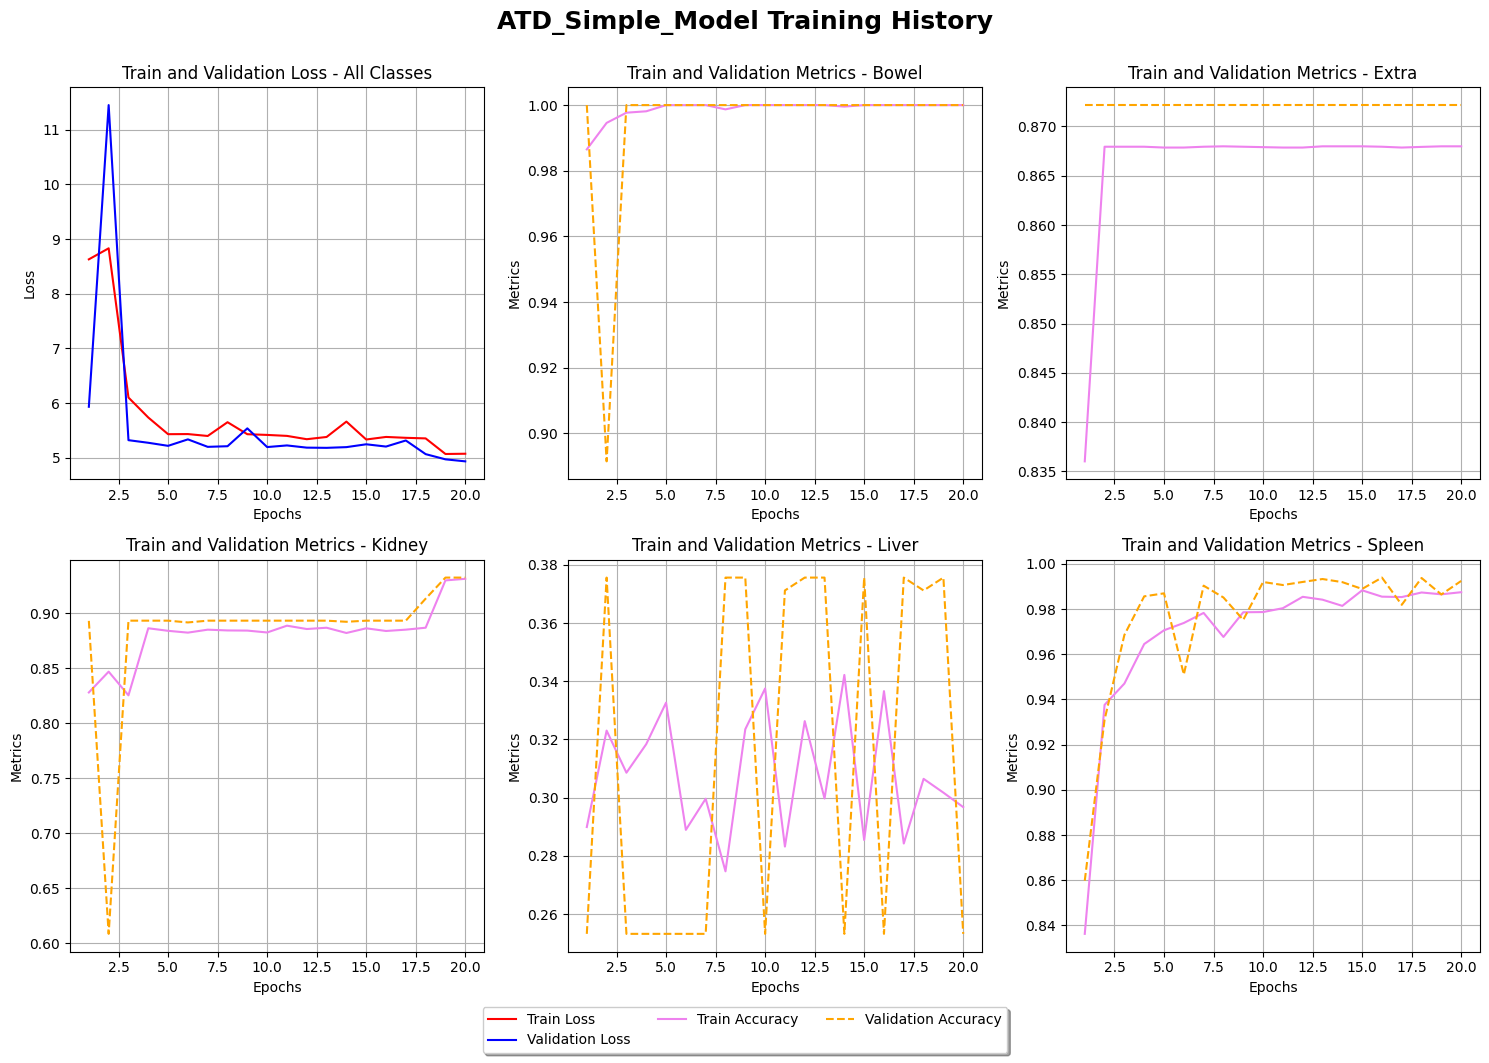

In [ ]:
from torch_helper_functions import plotting_utils
plotting_utils.plot_model_history_curves(ATD_Simple_Model_history)

## Step 12: Evaluating Trained Model On Test Data

In [ ]:
from torch_helper_functions import utils
utils.model_evaluation(ATD_Simple_Model,
                      dataloader=test_dataloader,
                      criterion_bowel=criterion_bowel,
                      criterion_extra=criterion_extra,
                      criterion_kidney=criterion_kidney,
                      criterion_liver=criterion_liver,
                      criterion_spleen=criterion_spleen)

Testing:   0%|          | 0/399 [00:00<?, ?it/s]

Test loss is: 5.0259
╒═══════════╤══════════╤═══════════════╤══════════╤═══════════╤══════════╕
│ Results   │    bowel │   extravation │   kidney │     liver │   spleen │
╞═══════════╪══════════╪═══════════════╪══════════╪═══════════╪══════════╡
│ Accuracy  │ 1        │      0.872807 │ 0.927921 │ 0.253133  │ 0.990494 │
├───────────┼──────────┼───────────────┼──────────┼───────────┼──────────┤
│ F1_Score  │ 0.365915 │      0        │ 0.941353 │ 0.0269859 │ 0.985221 │
╘═══════════╧══════════╧═══════════════╧══════════╧═══════════╧══════════╛ 



## Step 13: Plotting Confusion Matrix For All Labels

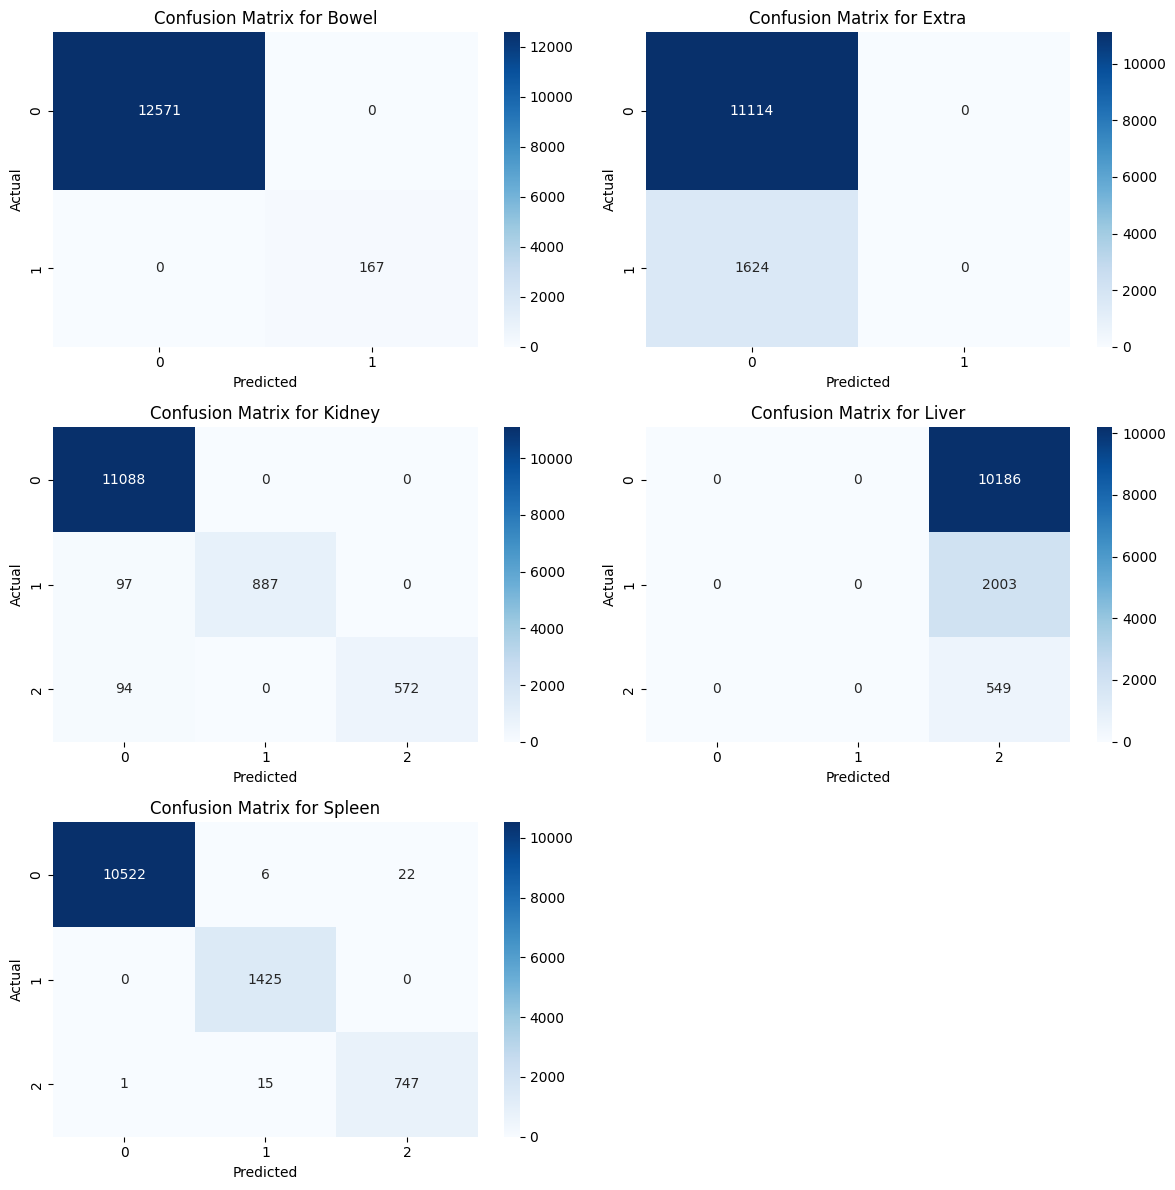

In [ ]:
from torch_helper_functions import plotting_utils
plotting_utils.generate_confusion_matrix(ATD_Simple_Model, test_dataloader)

## Step 14: Predicting Image Data With Our Model

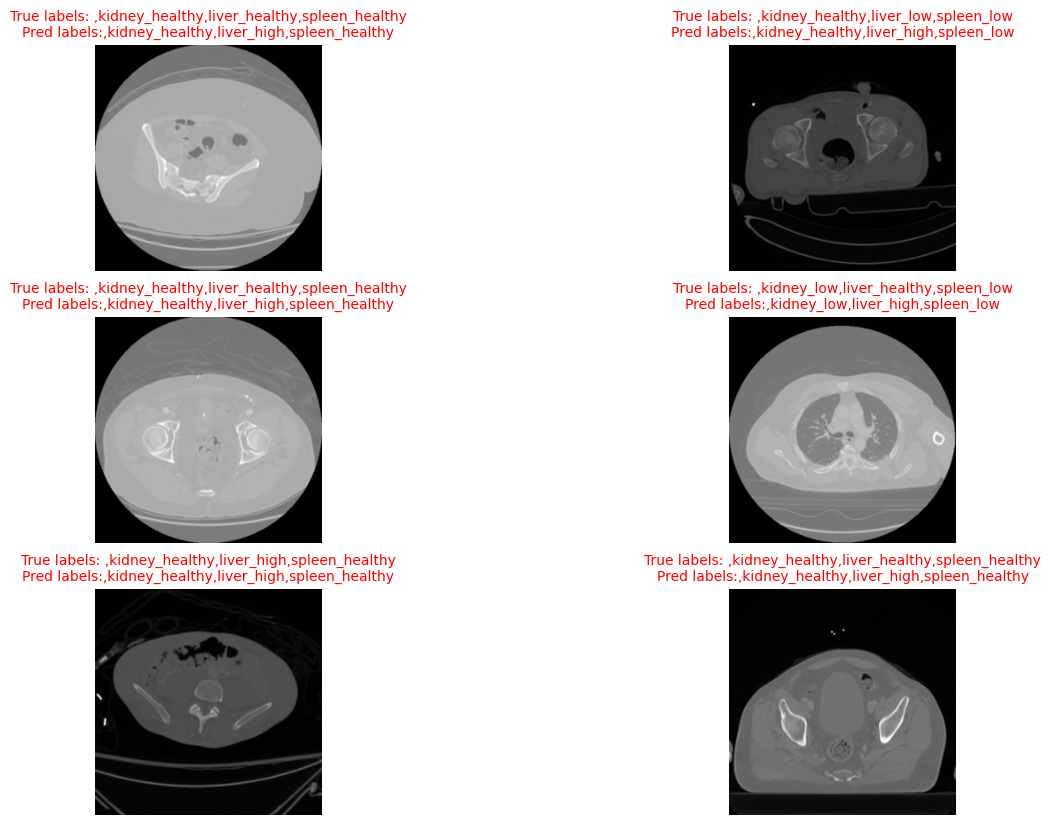

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
ATD_Simple_Model.eval()
# Visualizing labels and images
images,y_bowel, y_extra, y_kidney, y_liver, y_spleen = next(iter(test_dataloader))
# Forward pass
with torch.inference_mode():
  bowel_out, extra_out, kidney_out, liver_out, spleen_out = ATD_Simple_Model(images.to(device))

# Convert logits to predictions
bowel_preds = (torch.sigmoid(bowel_out) > 0.5).int().cpu().numpy().flatten()
extra_preds = (torch.sigmoid(extra_out) > 0.5).int().cpu().numpy().flatten()
kidney_preds = np.argmax(F.softmax(kidney_out, dim=1).cpu().numpy(), axis=1).flatten()
liver_preds = np.argmax(F.softmax(liver_out, dim=1).cpu().numpy(), axis=1).flatten()
spleen_preds = np.argmax(F.softmax(spleen_out, dim=1).cpu().numpy(), axis=1).flatten()
# Display sample data and labels
fig,ax = plt.subplots(3,2,figsize=(15,10))
ax = ax.ravel()
for k in range(6):
  label=''
  pred_label=''
  i = random.choice(range(0,31))
  ax[k].imshow(images[i].permute(1,2,0),cmap="gray")
  if y_bowel[i].item()==1:
    label+=","+label_columns[0]
  if y_extra[i].item()==1:
    label+=","+label_columns[1]
  label+=","+label_columns[2+y_kidney[i].argmax()]
  label+=","+label_columns[5+y_liver[i].argmax()]
  label+=","+label_columns[8+y_spleen[i].argmax()]

  if bowel_preds[i].item()==1:
    pred_label+=","+label_columns[0]
  if extra_preds[i].item()==1:
    pred_label+=","+label_columns[1]
  pred_label+=","+label_columns[2+kidney_preds[i]]
  pred_label+=","+label_columns[5+liver_preds[i]]
  pred_label+=","+label_columns[8+spleen_preds[i]]
  ax[k].set_title(f"True labels: {label}\nPred labels:{pred_label}",fontsize=10,color="r")
  ax[k].axis("off")